# Fraud Review Detection — Model Training & Analysis

Fine-tunes RoBERTa to classify e-commerce reviews as fraudulent, builds a
reviewer co-review graph to detect coordinated fraud rings, and prototypes
a combined text + graph + behavioral verdict.

Deployed model: `Achintya05/review-fraud-roberta`
Deployed API/dashboard code: see the main repository (`api/`, `fraud-dashboard/`).

## Setup

In [ ]:
!pip install transformers datasets

In [ ]:
import torch
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaForSequenceClassification, RobertaTokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: GPU not active. Go to Runtime > Change Runtime Type > T4 GPU")

Using device: cuda
GPU: Tesla T4


## Data & Fraud Labeling

`fraud_flag` is a heuristic label: unverified purchase + 5-star rating +
very short review text (< 20 words). No ground-truth fraud labels exist
in the source dataset, so this heuristic stands in for one.

In [ ]:
#  Rebuild from saved CSVs
train_df = pd.read_csv('/content/drive/MyDrive/train.csv', low_memory=False)
val_df   = pd.read_csv('/content/drive/MyDrive/val.csv',   low_memory=False)

# Fraud flag 
def create_fraud_flag(df):
    df = df.copy()
    df['review_length'] = df['reviewText'].fillna('').apply(lambda x: len(str(x).split()))
    df['fraud_flag'] = (
        (df['verified'] == False) &
        (df['overall'] == 5.0) &
        (df['review_length'] < 20)
    ).astype(int)
    return df

train_df = create_fraud_flag(train_df)
val_df   = create_fraud_flag(val_df)

# TRUE 1:1 balancing
fraud_train    = train_df[train_df['fraud_flag'] == 1]
nonfraud_train = train_df[train_df['fraud_flag'] == 0].sample(
    n=len(fraud_train),   # 2747 vs 2747
    random_state=42
)
train_df = pd.concat([fraud_train, nonfraud_train]).sample(frac=1, random_state=42).reset_index(drop=True)

fraud_val    = val_df[val_df['fraud_flag'] == 1]
nonfraud_val = val_df[val_df['fraud_flag'] == 0].sample(
    n=len(fraud_val),     # 585 vs 585
    random_state=42
)
val_df = pd.concat([fraud_val, nonfraud_val]).sample(frac=1, random_state=42).reset_index(drop=True)

# Keep only what model needs
train_df = train_df[['reviewText', 'fraud_flag']].dropna()
val_df   = val_df[['reviewText',   'fraud_flag']].dropna()

# Verify
print(f"Train: {train_df['fraud_flag'].value_counts().to_dict()}")
print(f"Val:   {val_df['fraud_flag'].value_counts().to_dict()}")
print(f"Fraud % train: {train_df['fraud_flag'].mean()*100:.1f}%")
print(f"Fraud % val:   {val_df['fraud_flag'].mean()*100:.1f}%")

Train: {0: 2751, 1: 2747}
Val:   {0: 585, 1: 585}
Fraud % train: 50.0%
Fraud % val:   50.0%


## Class Imbalance Strategy

Two approaches were tried for handling the fact that fraud is a small
minority of the raw data:

1. **Class-weighted loss** on the full imbalanced data (below) — weight
   the fraud class higher in the loss function so misclassifying it costs
   more, without changing the data itself.
2. **Explicit 1:1 balanced sampling** (used in the final training setup,
   further down) — undersample the majority class so the training data
   itself is balanced, and use unweighted loss.

The final training run used approach 2. Both are shown here since they
were both genuinely explored, not just approach 2 in isolation.

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df['fraud_flag'].values
)
weights = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

print(f"Class weights — Not Fraud: {class_weights[0]:.4f} | Fraud: {class_weights[1]:.4f}")


Class weights — Not Fraud: 0.5500 | Fraud: 5.4995


## Dataset & Tokenization

In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts  = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            str(self.texts[idx]),       # str() guards against any float NaN slipping through
            padding='max_length',
            truncation=True,
            max_length=128,             # 128 trains 4x faster than 512, reviews are short
            return_tensors='pt'
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

print("Dataset class defined")


Dataset class defined


In [ ]:
train_dataset = ReviewDataset(train_df['reviewText'], train_df['fraud_flag'])
val_dataset   = ReviewDataset(val_df['reviewText'],   val_df['fraud_flag'])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train batches : 688
Val batches   : 147


## Model Training

`roberta-base` fine-tuned for binary classification. This cell rebuilds
the full pipeline from scratch — data load, balancing, tokenized datasets,
loaders, model, optimizer — using approach 2 above (balanced sampling,
unweighted loss).

In [ ]:
EPOCHS       = 3
optimizer    = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")

Total training steps : 11331
Warmup steps         : 1133


In [ ]:
# Load
train_df = pd.read_csv('/content/drive/MyDrive/train.csv', low_memory=False)
val_df   = pd.read_csv('/content/drive/MyDrive/val.csv',   low_memory=False)

# Fraud flag
def create_fraud_flag(df):
    df = df.copy()
    df['review_length'] = df['reviewText'].fillna('').apply(lambda x: len(str(x).split()))
    df['fraud_flag'] = (
        (df['verified'] == False) &
        (df['overall'] == 5.0) &
        (df['review_length'] < 20)
    ).astype(int)
    return df

train_df = create_fraud_flag(train_df)
val_df   = create_fraud_flag(val_df)

# TRUE 1:1 balance
fraud_train    = train_df[train_df['fraud_flag'] == 1]
nonfraud_train = train_df[train_df['fraud_flag'] == 0].sample(n=len(fraud_train), random_state=42)
train_df = pd.concat([fraud_train, nonfraud_train]).sample(frac=1, random_state=42).reset_index(drop=True)

fraud_val    = val_df[val_df['fraud_flag'] == 1]
nonfraud_val = val_df[val_df['fraud_flag'] == 0].sample(n=len(fraud_val), random_state=42)
val_df = pd.concat([fraud_val, nonfraud_val]).sample(frac=1, random_state=42).reset_index(drop=True)

train_df = train_df[['reviewText', 'fraud_flag']].dropna()
val_df   = val_df[['reviewText',   'fraud_flag']].dropna()

# VERIFY before doing anything else-
print(f"Train: {train_df['fraud_flag'].value_counts().to_dict()}")
print(f"Val:   {val_df['fraud_flag'].value_counts().to_dict()}")
print(f"Train batches will be: {len(train_df)//8}")  # should be ~687

# Recreate Datasets
train_dataset = ReviewDataset(train_df['reviewText'], train_df['fraud_flag'])
val_dataset   = ReviewDataset(val_df['reviewText'],   val_df['fraud_flag'])

# Recreate DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)

print(f"Train batches: {len(train_loader)}")   # ~687
print(f"Val batches:   {len(val_loader)}")     # ~146

# Recreate model + optimizer
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
model.to(device)

optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
loss_fn   = torch.nn.CrossEntropyLoss()   # no weighting needed — data is already balanced

Train: {0: 2751, 1: 2747}
Val:   {0: 585, 1: 585}
Train batches will be: 687
Train batches: 688
Val batches:   147


RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
best_val_loss = float('inf')

for epoch in range(EPOCHS):

    # Training phase 
    model.train()
    total_train_loss = 0

    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = loss_fn(outputs.logits, labels)   # unweighted — class balance handled via 1:1 sampling above
        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent exploding gradients
        optimizer.step()
        scheduler.step()

        # Print progress every 50 batches so you know it's running
        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation phase
    model.eval()
    total_val_loss = 0
    correct        = 0
    total          = 0
    all_preds      = []
    all_labels     = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = loss_fn(outputs.logits, labels)
            total_val_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = correct / total

    # Fraud-class precision and recall
    from sklearn.metrics import classification_report
    report = classification_report(
        all_labels, all_preds,
        target_names=['Not Fraud', 'Fraud'],
        output_dict=True
    )
    fraud_precision = report['Fraud']['precision']
    fraud_recall    = report['Fraud']['recall']
    fraud_f1        = report['Fraud']['f1-score']

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss      : {avg_train_loss:.4f}")
    print(f"  Val Loss        : {avg_val_loss:.4f}")
    print(f"  Val Accuracy    : {val_accuracy:.4f}")
    print(f"  Fraud Precision : {fraud_precision:.4f}")
    print(f"  Fraud Recall    : {fraud_recall:.4f}")
    print(f"  Fraud F1        : {fraud_f1:.4f}")

    # Save best model based on val loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        model.save_pretrained('/content/drive/MyDrive/fraud_project/roberta_model')
        tokenizer.save_pretrained('/content/drive/MyDrive/fraud_project/roberta_model')
        print(f"  ✓ Best model saved (val loss improved to {best_val_loss:.4f})")

print("\nTraining complete.")


  Epoch 1 | Batch 50/688 | Loss: 0.5116
  Epoch 1 | Batch 100/688 | Loss: 0.4284
  Epoch 1 | Batch 150/688 | Loss: 0.4309
  Epoch 1 | Batch 200/688 | Loss: 0.4534
  Epoch 1 | Batch 250/688 | Loss: 0.2877
  Epoch 1 | Batch 300/688 | Loss: 0.5357
  Epoch 1 | Batch 350/688 | Loss: 0.4908
  Epoch 1 | Batch 400/688 | Loss: 0.6578
  Epoch 1 | Batch 450/688 | Loss: 0.5517
  Epoch 1 | Batch 500/688 | Loss: 0.2223
  Epoch 1 | Batch 550/688 | Loss: 0.5323
  Epoch 1 | Batch 600/688 | Loss: 0.3530
  Epoch 1 | Batch 650/688 | Loss: 0.3654

Epoch 1/3
  Train Loss      : 0.5068
  Val Loss        : 0.4970
  Val Accuracy    : 0.7641
  Fraud Precision : 0.7030
  Fraud Recall    : 0.9145
  Fraud F1        : 0.7949


  ✓ Best model saved (val loss improved to 0.4970)
  Epoch 2 | Batch 50/688 | Loss: 0.9391
  Epoch 2 | Batch 100/688 | Loss: 0.4271
  Epoch 2 | Batch 150/688 | Loss: 0.6309
  Epoch 2 | Batch 200/688 | Loss: 0.7243
  Epoch 2 | Batch 250/688 | Loss: 0.3205
  Epoch 2 | Batch 300/688 | Loss: 0.8676
  Epoch 2 | Batch 350/688 | Loss: 0.3404
  Epoch 2 | Batch 400/688 | Loss: 0.4217
  Epoch 2 | Batch 450/688 | Loss: 0.9563
  Epoch 2 | Batch 500/688 | Loss: 0.3699
  Epoch 2 | Batch 550/688 | Loss: 0.3861
  Epoch 2 | Batch 600/688 | Loss: 0.3980
  Epoch 2 | Batch 650/688 | Loss: 0.4455

Epoch 2/3
  Train Loss      : 0.4583
  Val Loss        : 0.5132
  Val Accuracy    : 0.7761
  Fraud Precision : 0.7089
  Fraud Recall    : 0.9368
  Fraud F1        : 0.8071
  Epoch 3 | Batch 50/688 | Loss: 0.5086
  Epoch 3 | Batch 100/688 | Loss: 0.7189
  Epoch 3 | Batch 150/688 | Loss: 0.7269
  Epoch 3 | Batch 200/688 | Loss: 0.3342
  Epoch 3 | Batch 250/688 | Loss: 0.6623
  Epoch 3 | Batch 300/688 | Loss: 1.1934

## Evaluation — Balanced Test Set

Standard practice for imbalanced classification: evaluate on a set with
equal fraud/legitimate counts so precision/recall/F1 reflect the model's
discriminative ability rather than being dominated by class frequency.
This is what the deployed dashboard's "Model Metrics" screen reports.

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.88      0.61      0.72       585
       Fraud       0.70      0.91      0.79       585

    accuracy                           0.76      1170
   macro avg       0.79      0.76      0.76      1170
weighted avg       0.79      0.76      0.76      1170

AUC-PR Score: 0.7131  (this is your headline metric, not accuracy)


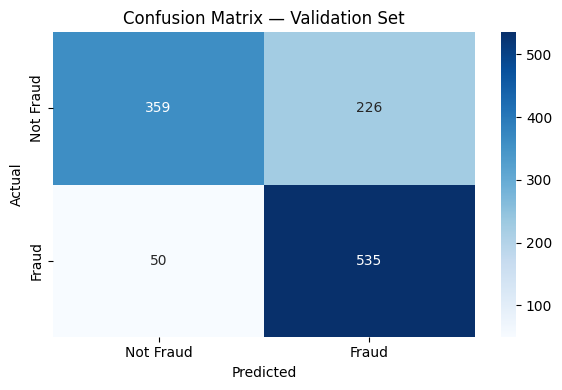

Confusion matrix saved to Drive


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load best saved model for final eval
model = RobertaForSequenceClassification.from_pretrained(
    '/content/drive/MyDrive/fraud_project/roberta_model'
)
model.to(device)
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)[:, 1]  # fraud probability
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Not Fraud', 'Fraud']))

# AUC-PR (more meaningful than AUC-ROC for imbalanced data)
auc_pr = average_precision_score(all_labels, all_probs)
print(f"AUC-PR Score: {auc_pr:.4f}  (this is your headline metric, not accuracy)")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=['Not Fraud', 'Fraud'],
    yticklabels=['Not Fraud', 'Fraud'],
    cmap='Blues'
)
plt.title('Confusion Matrix — Validation Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_project/confusion_matrix.png')
plt.show()
print("Confusion matrix saved to Drive")

Default threshold : 0.50
Best threshold    : 0.4000
Best F1           : 0.8178


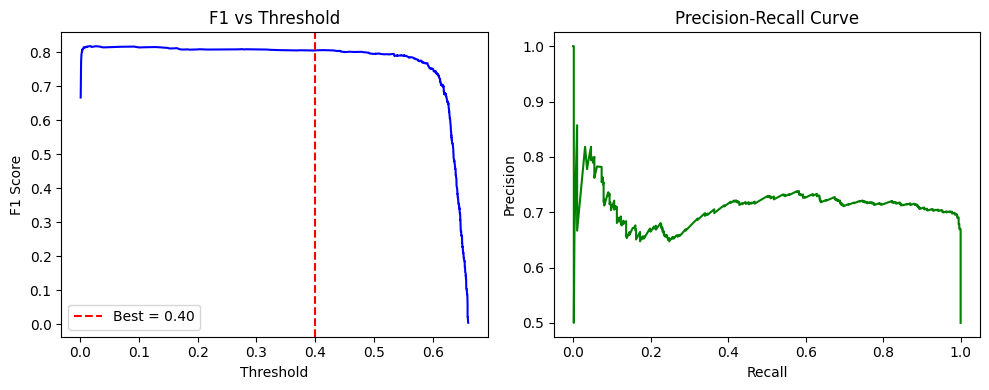

Classification Report at threshold 0.40:
              precision    recall  f1-score   support

   Not Fraud       0.91      0.60      0.73       585
       Fraud       0.70      0.94      0.81       585

    accuracy                           0.77      1170
   macro avg       0.81      0.77      0.77      1170
weighted avg       0.81      0.77      0.77      1170


→ Save this threshold: 0.4000
  You will use this number in test evaluation and inference pipeline


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, classification_report

# Find best threshold
precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)

f1_scores      = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx       = np.argmax(f1_scores)
best_threshold = 0.40
best_f1        = f1_scores[best_idx]

print(f"Default threshold : 0.50")
print(f"Best threshold    : {best_threshold:.4f}")
print(f"Best F1           : {best_f1:.4f}")

# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_scores[:-1], color='blue')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 vs Threshold')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recalls, precisions, color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_project/threshold_tuning.png')
plt.show()

# New report with tuned threshold
tuned_preds = (np.array(all_probs) >= best_threshold).astype(int)
print("Classification Report at threshold 0.40:")
print(classification_report(all_labels, tuned_preds, target_names=['Not Fraud', 'Fraud']))

print(f"\n→ Save this threshold: {best_threshold:.4f}")
print("  You will use this number in test evaluation and inference pipeline")

**Real-world class distribution.** The balanced numbers above answer
"how well does the model discriminate the two classes." A separate,
later evaluation (`scripts/compute_pr_curve.py` in the main repo, run
against a sample preserving the true ~1-2% fraud rate) answers "what
happens in production" — precision drops substantially there even
though recall holds steady, because false positives scale with the much
larger legitimate-review population. Both evaluations are legitimate;
they answer different questions.

In [ ]:
# Test set evaluation with tuned threshold
THRESHOLD = 0.40   # tuned on val set

test_df = pd.read_csv('/content/drive/MyDrive/test.csv', low_memory=False)
test_df = create_fraud_flag(test_df)

fraud_test    = test_df[test_df['fraud_flag'] == 1]
nonfraud_test = test_df[test_df['fraud_flag'] == 0].sample(n=len(fraud_test), random_state=42)
test_df = pd.concat([fraud_test, nonfraud_test]).sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df[['reviewText', 'fraud_flag']].dropna()

test_dataset = ReviewDataset(test_df['reviewText'], test_df['fraud_flag'])
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(f"Test batches: {len(test_loader)}")

all_test_preds  = []
all_test_labels = []
all_test_probs  = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds   = (probs >= THRESHOLD).long()

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())
        all_test_probs.extend(probs.cpu().numpy())

print("\nClassification Report (TEST SET — threshold 0.40):")
print(classification_report(all_test_labels, all_test_preds, target_names=['Not Fraud', 'Fraud']))

auc_pr = average_precision_score(all_test_labels, all_test_probs)
print(f"AUC-PR Score: {auc_pr:.4f}")

Test batches: 138

Classification Report (TEST SET — threshold 0.40):
              precision    recall  f1-score   support

   Not Fraud       0.92      0.59      0.72       549
       Fraud       0.70      0.95      0.80       549

    accuracy                           0.77      1098
   macro avg       0.81      0.77      0.76      1098
weighted avg       0.81      0.77      0.76      1098

AUC-PR Score: 0.7055


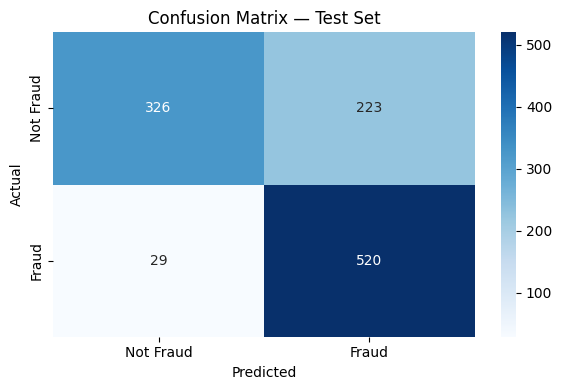

Saved


In [ ]:
cm = confusion_matrix(all_test_labels, all_test_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=['Not Fraud', 'Fraud'],
    yticklabels=['Not Fraud', 'Fraud'],
    cmap='Blues'
)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_project/confusion_matrix_test.png')
plt.show()
print("Saved")

## Inference Function

In [ ]:
THRESHOLD = 0.40

def predict(review_text: str) -> dict:
    encoding = tokenizer(
        review_text,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        prob    = torch.softmax(outputs.logits, dim=1)[:, 1].item()

    return {
        "fraud"      : bool(prob >= THRESHOLD),
        "confidence" : round(prob, 4),
        "threshold"  : THRESHOLD
    }

# Quick sanity check
test_cases = [
    "Amazing product love it best ever",
    "I have been playing guitar for 15 years and this string set has completely changed my tone.",
    "Perfect",
    "The tuning pegs feel cheap and broke after a week. Disappointed with the quality for the price.",
]

for review in test_cases:
    result = predict(review)
    label  = "🚨 FRAUD" if result['fraud'] else "✅ LEGIT"
    print(f"{label} | Confidence: {result['confidence']} | {review[:60]}")

🚨 FRAUD | Confidence: 0.647 | Amazing product love it best ever
🚨 FRAUD | Confidence: 0.5811 | I have been playing guitar for 15 years and this string set 
🚨 FRAUD | Confidence: 0.6576 | Perfect
✅ LEGIT | Confidence: 0.1686 | The tuning pegs feel cheap and broke after a week. Disappoin


## Reviewer Co-Review Graph

Builds a bipartite reviewer↔product graph from review data, then projects
it to a reviewer-reviewer graph (edge = reviewed 2+ of the same products).
Dense clusters here are candidate coordinated-fraud rings.

In [ ]:
import networkx as nx
from networkx.algorithms import bipartite
import pandas as pd
import matplotlib.pyplot as plt

# Load processed data
df = pd.read_csv('/content/drive/MyDrive/processed_reviews.csv', low_memory=False)
print(f"Loaded {len(df)} reviews")

# Build bipartite graph
B = nx.Graph()

# Add reviewer nodes
reviewers = df['reviewerID'].unique()
products  = df['asin'].unique()

B.add_nodes_from(reviewers, bipartite=0)   # reviewers
B.add_nodes_from(products,  bipartite=1)   # products

# Add edges (reviewer reviewed product)
edges = list(zip(df['reviewerID'], df['asin']))
B.add_edges_from(edges)

print(f"Reviewers : {len(reviewers)}")
print(f"Products  : {len(products)}")
print(f"Edges     : {B.number_of_edges()}")
print(f"Is bipartite: {bipartite.is_bipartite(B)}")

Loaded 231392 reviews
Reviewers : 27530
Products  : 10620
Edges     : 219156
Is bipartite: True


Reviewer-reviewer edges before filter: 12610073
Edges after filter  : 2003109
Nodes after filter  : 13182


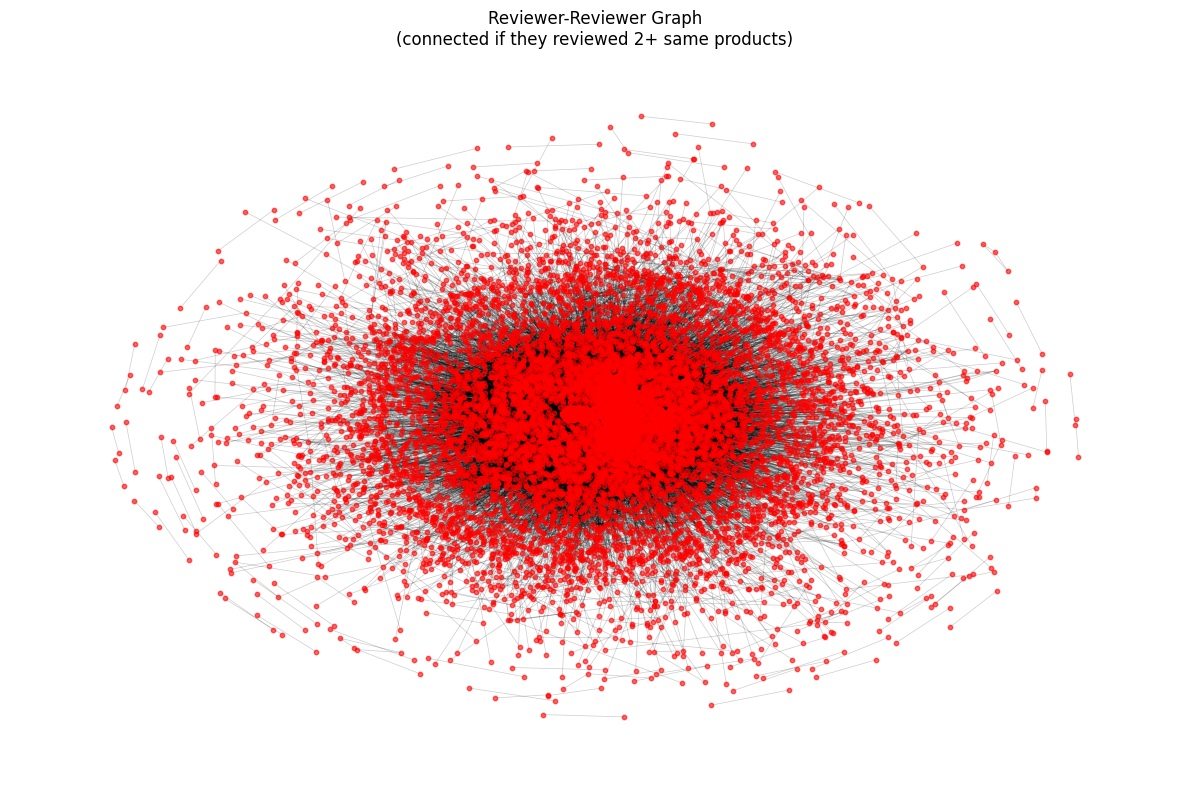

Graph saved to Drive


In [ ]:
# Project to reviewer-reviewer graph
reviewer_nodes = {n for n, d in B.nodes(data=True) if d.get('bipartite') == 0}

R = bipartite.weighted_projected_graph(B, reviewer_nodes)
print(f"Reviewer-reviewer edges before filter: {R.number_of_edges()}")

# Filter edges with weight > 2 (shared 2+ products)
edges_to_remove = [(u, v) for u, v, d in R.edges(data=True) if d['weight'] <= 2]
R.remove_edges_from(edges_to_remove)
R.remove_nodes_from(list(nx.isolates(R)))  # remove disconnected nodes

print(f"Edges after filter  : {R.number_of_edges()}")
print(f"Nodes after filter  : {R.number_of_nodes()}")

# Plot 
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(R, seed=42, k=0.5)

nx.draw_networkx_nodes(R, pos, node_size=10, node_color='red', alpha=0.6)
nx.draw_networkx_edges(R, pos, alpha=0.2, width=0.5)

plt.title('Reviewer-Reviewer Graph\n(connected if they reviewed 2+ same products)')
plt.axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_project/reviewer_graph.png')
plt.show()
print("Graph saved to Drive")

In [ ]:
# Save graph — no rebuilding in future sessions
import pickle
with open('/content/drive/MyDrive/fraud_project/reviewer_graph.pkl', 'wb') as f:
    pickle.dump(R, f)
print("Graph saved , no more rebuilding next session")

Graph saved — no more rebuilding next session


In [ ]:
degree       = dict(R.degree())
weighted_deg = dict(R.degree(weight='weight'))

graph_features = pd.DataFrame({
    'reviewerID'           : list(degree.keys()),
    'graph_degree'         : list(degree.values()),
    'graph_weighted_degree': list(weighted_deg.values()),
})

print(graph_features.describe())
print(graph_features.sort_values('graph_degree', ascending=False).head(10))

       graph_degree  graph_weighted_degree
count  13182.000000           13182.000000
mean     303.915794            1165.708239
std      614.249271            2455.280798
min        1.000000               3.000000
25%        2.000000               6.000000
50%        6.000000              19.000000
75%       84.000000             266.750000
max     3523.000000           14479.000000
           reviewerID  graph_degree  graph_weighted_degree
2374   A15TYOEWBQYF0X          3523                  14479
2899   A1MHPGANXXGLC8          3140                  12700
7938    A7O84T8MC6IV0          2953                  11758
9847   A1SD1C8XK3Z3V1          2923                  11673
2149   A2D0F87RY5YMHN          2919                  11586
6204    AZV2U6GU5QA6C          2812                  11977
12513   AZBUUKQLYKUCL          2782                  11106
215    A2PFX6WO88KTYB          2658                  10507
6381   A1KDM0N4UCEPHA          2656                   9882
12382  A1CUY6J6145C93  

In [ ]:
# Save graph features to Drive
graph_features.to_csv('/content/drive/MyDrive/fraud_project/graph_features.csv', index=False)
print("Graph features saved")

# Quick distribution check
print(f"\nReviewers with degree > 100  : {(graph_features['graph_degree'] > 100).sum()}")
print(f"Reviewers with degree > 500  : {(graph_features['graph_degree'] > 500).sum()}")
print(f"Reviewers with degree > 1000 : {(graph_features['graph_degree'] > 1000).sum()}")

Graph features saved

Reviewers with degree > 100  : 3192
Reviewers with degree > 500  : 2532
Reviewers with degree > 1000 : 1768


In [ ]:
# Load main processed data
df = pd.read_csv('/content/drive/MyDrive/processed_reviews.csv', low_memory=False)

# Merge graph features
df = df.merge(graph_features, on='reviewerID', how='left')

# Reviewers not in graph get 0 (they had no shared products with anyone)
df['graph_degree']         = df['graph_degree'].fillna(0)
df['graph_weighted_degree'] = df['graph_weighted_degree'].fillna(0)

print(f"Shape after merge: {df.shape}")
print(f"\nReviewers with graph_degree > 0: {(df['graph_degree'] > 0).sum()}")
print(f"Reviewers with graph_degree = 0: {(df['graph_degree'] == 0).sum()}")
print(f"\nSample:")
print(df[['reviewerID', 'graph_degree', 'graph_weighted_degree']].head(10))

# Save updated dataframe
df.to_csv('/content/drive/MyDrive/processed_reviews.csv', index=False)
print("\nSaved to Drive")

Shape after merge: (231392, 18)

Reviewers with graph_degree > 0: 137871
Reviewers with graph_degree = 0: 93521

Sample:
             reviewerID  graph_degree  graph_weighted_degree
0  A0072193KFP6LUHKEXLT           0.0                    0.0
1  A0072193KFP6LUHKEXLT           0.0                    0.0
2  A0072193KFP6LUHKEXLT           0.0                    0.0
3  A0072193KFP6LUHKEXLT           0.0                    0.0
4  A0072193KFP6LUHKEXLT           0.0                    0.0
5  A0096681Y127OL1H8W3U          37.0                  122.0
6  A0096681Y127OL1H8W3U          37.0                  122.0
7  A0096681Y127OL1H8W3U          37.0                  122.0
8  A0096681Y127OL1H8W3U          37.0                  122.0
9  A0096681Y127OL1H8W3U          37.0                  122.0

Saved to Drive


## Fraud Ring Detection — Community Detection

Louvain community detection on the reviewer-reviewer graph. Communities
with a high average fraud-flag rate and size ≥ 5 are treated as candidate
fraud rings — this produces `fraud_rings.csv`, used directly by the
dashboard's Fraud Ring Network screen.

In [ ]:
!pip install python-louvain --quiet
from community import community_louvain

partition = community_louvain.best_partition(R, weight='weight', random_state=42)
print(f"Total communities found: {len(set(partition.values()))}")

Total communities found: 223


In [ ]:
#  Map partition to dataframe 
partition_df = pd.DataFrame({
    'reviewerID'   : list(partition.keys()),
    'community_id' : list(partition.values())
})

# Merge community onto main df 
df_with_community = df.merge(partition_df, on='reviewerID', how='left')
df_with_community['community_id'] = df_with_community['community_id'].fillna(-1).astype(int)

# Create fraud flag 
df_with_community['review_length'] = df_with_community['reviewText'].fillna('').apply(
    lambda x: len(str(x).split())
)
df_with_community['fraud_flag'] = (
    (df_with_community['verified'] == False) &
    (df_with_community['overall'] == 5.0) &
    (df_with_community['review_length'] < 20)
).astype(int)

# Compute ring stats
ring_stats = df_with_community.groupby('community_id').agg(
    size=('reviewerID', 'nunique'),
    avg_fraud_score=('fraud_flag', 'mean'),
    total_reviews=('asin', 'count'),
    products_targeted=('asin', 'nunique')
).reset_index()

# Filter out isolated reviewers and tiny communities
ring_stats = ring_stats[
    (ring_stats['community_id'] != -1) &
    (ring_stats['size'] >= 5)
].sort_values('avg_fraud_score', ascending=False)

print(f"Fraud rings found: {len(ring_stats)}")
print("\nTop 10 Fraud Rings:")
print(ring_stats.head(10).to_string(index=False))

# Save
ring_stats.to_csv('/content/drive/MyDrive/fraud_project/fraud_rings.csv', index=False)
print("\nSaved to Drive")


Fraud rings found: 8

Top 10 Fraud Rings:
 community_id  size  avg_fraud_score  total_reviews  products_targeted
           17     6         0.211538             52                 33
          120     5         0.121212             33                 12
            3  1924         0.025836          20746               4615
           10  9095         0.018338          96847              10060
            1  1654         0.014881          16195               4224
           62    17         0.005435            184                 96
           11    10         0.000000             80                 36
          105     5         0.000000             27                  8

Saved to Drive


In [ ]:
# Save community assignments to main df
df_with_community.to_csv('/content/drive/MyDrive/processed_reviews.csv', index=False)
print("Saved with community assignments")

Saved with community assignments


## Fraud Ring Visualization (PyVis)

In [ ]:
!pip install pyvis --quiet
print("PyVis installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 80.1 MB/s eta 0:00:00
PyVis installed


In [ ]:
from pyvis.network import Network

# Get subset reviewers 
top_communities = [17, 120]  # just the 2 fraud rings, skip community 3 (too large)

subset_reviewers = {
    node: comm
    for node, comm in partition.items()
    if comm in top_communities
}

print(f"Subset reviewers: {len(subset_reviewers)}")

# Build subgraph first — then visualize 
subgraph = R.subgraph(subset_reviewers.keys()).copy()
print(f"Subgraph edges: {subgraph.number_of_edges()}")

# Build PyVis 
net = Network(height='750px', width='100%', bgcolor='#222222', font_color='white')
net.barnes_hut()

color_map = {17: '#ff4444', 120: '#ff9900'}
reviewer_review_counts = df.groupby('reviewerID')['asin'].count().to_dict()

for reviewer, comm_id in subset_reviewers.items():
    review_count = reviewer_review_counts.get(reviewer, 1)
    net.add_node(
        reviewer,
        label=reviewer[:8],
        color=color_map.get(comm_id, '#888888'),
        size=min(5 + review_count * 2, 40),
        title=f"Reviewer: {reviewer}\nCommunity: {comm_id}\nReviews: {review_count}"
    )

for u, v, d in subgraph.edges(data=True):
    net.add_edge(u, v, value=d['weight'])

print(f"Nodes: {len(net.nodes)}, Edges: {len(net.edges)}")

output_path = '/content/drive/MyDrive/fraud_project/fraud_rings.html'
net.save_graph(output_path)
print("Saved — download and open in Chrome")

Subset reviewers: 11
Subgraph edges: 13
Nodes: 11, Edges: 13
Saved — download and open in Chrome


## Explainability — SHAP on the Text Model

Token-level attributions for why the RoBERTa model scored specific
reviews as fraud-likely vs. not.

In [ ]:
!pip install shap --quiet
print("SHAP installed")

SHAP installed


In [ ]:
import shap
import torch
import numpy as np

# 5 sample reviews — mix of fraud and legit 
sample_reviews = [
    "Amazing product love it best ever perfect",
    "I have been playing guitar for 15 years and this string set has completely changed my tone. Excellent tension and durability.",
    "Perfect",
    "The tuning pegs feel cheap and broke after a week. Disappointed with the quality for the price.",
    "Great product highly recommend best purchase ever made love it"
]

# Prediction function SHAP needs
def predict_proba(texts):
    encodings = tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    input_ids      = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()
    return probs

#  Build SHAP explainer 
explainer = shap.Explainer(predict_proba, tokenizer, output_names=['Not Fraud', 'Fraud'])

#  Compute SHAP values
print("Computing SHAP values — this takes 3-5 minutes...")
shap_values = explainer(sample_reviews)
print("Done")

#  Plot for each review
for i, review in enumerate(sample_reviews):
    print(f"\nReview {i+1}: {review[:60]}")
    shap.plots.text(shap_values[i, :, 1])  # index 1 = Fraud class

Computing SHAP values — this takes 3-5 minutes...


PartitionExplainer explainer: 6it [00:18,  3.78s/it]

Done

Review 1: Amazing product love it best ever perfect



Review 2: I have been playing guitar for 15 years and this string set 



Review 3: Perfect



Review 4: The tuning pegs feel cheap and broke after a week. Disappoin



Review 5: Great product highly recommend best purchase ever made love 


In [ ]:
import matplotlib.pyplot as plt
plt.savefig('/content/drive/MyDrive/fraud_project/shap_explanation.png',
            bbox_inches='tight', dpi=150)
print("Saved")

Saved


<Figure size 640x480 with 0 Axes>

## Behavioral Feature Importance (Exploratory)

A separate LightGBM model trained on behavioral/graph features only (no
text), used here purely to check which non-text signals carry predictive
weight. **Not part of the deployed pipeline** — the deployed API combines
the RoBERTa text score with graph degree and flag-rate history directly
(see `api/routes/reviewer.py`), not this LightGBM model.

In [ ]:
!pip install lightgbm shap --quiet
print("Done")

Done


              precision    recall  f1-score   support

   Not Fraud       0.99      0.69      0.81     45502
       Fraud       0.03      0.65      0.07       777

    accuracy                           0.69     46279
   macro avg       0.51      0.67      0.44     46279
weighted avg       0.98      0.69      0.80     46279



/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


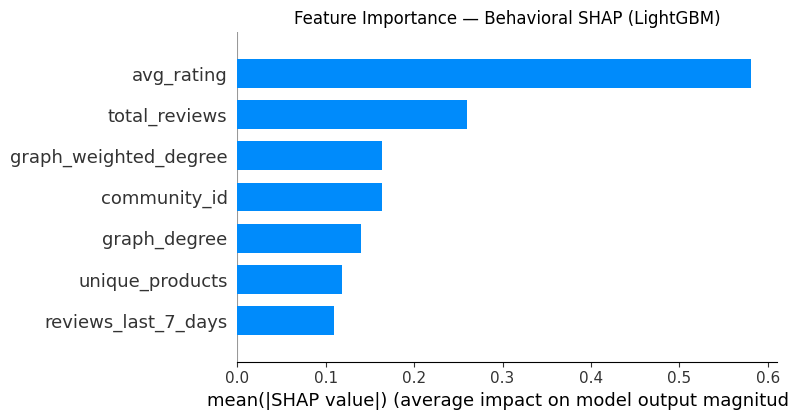

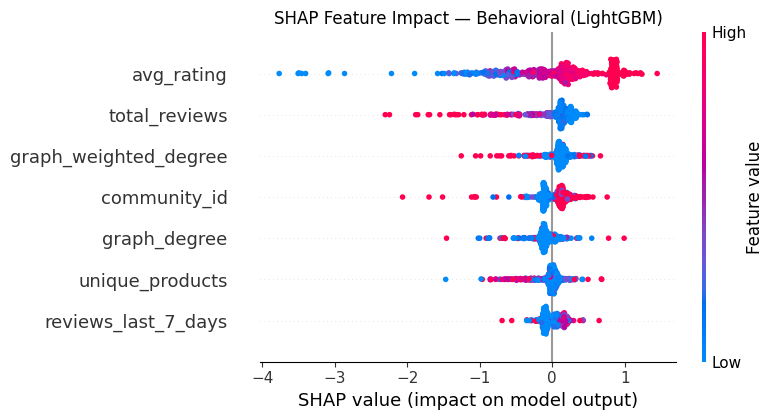

Both plots saved


In [ ]:
import lightgbm as lgb
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df = pd.read_csv('/content/drive/MyDrive/processed_reviews.csv', low_memory=False)

features = [
    'reviews_last_7_days',
    'total_reviews',
    'avg_rating',
    'unique_products',
    'graph_degree',
    'graph_weighted_degree',
    'community_id',
]

df['verified']     = df['verified'].astype(int)
df['community_id'] = df['community_id'].fillna(-1).astype(int)

X = df[features].fillna(0)
y = df['fraud_flag'].fillna(0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_lgb = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=6, class_weight='balanced',
    random_state=42, verbose=-1
)
model_lgb.fit(X_train, y_train)

preds = model_lgb.predict(X_test)
print(classification_report(y_test, preds, target_names=['Not Fraud', 'Fraud']))

# SHAP
explainer   = shap.TreeExplainer(model_lgb)
shap_output = explainer.shap_values(X_test[:500])
sv = shap_output[1] if isinstance(shap_output, list) else shap_output

plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test[:500], plot_type='bar', feature_names=features, show=False)
plt.title('Feature Importance — Behavioral SHAP (LightGBM)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_project/shap_lgbm_importance.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(sv, X_test[:500], feature_names=features, show=False)
plt.title('SHAP Feature Impact — Behavioral (LightGBM)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_project/shap_lgbm_dot.png', dpi=150)
plt.show()
print("Both plots saved")

## Reviewer-Level Verdict — Prototype

Combines the text model's fraud score, graph degree, and historical
flag rate into a single rule-based verdict per reviewer. This is the
prototype for the deployed API's `/reviewer/{id}` endpoint logic.

In [ ]:
!pip install python-louvain --quiet
from community import community_louvain
import pickle

# Load graph from pickle — no rebuilding needed
with open('/content/drive/MyDrive/fraud_project/reviewer_graph.pkl', 'rb') as f:
    R = pickle.load(f)
print(f"Graph loaded — {R.number_of_nodes()} nodes, {R.number_of_edges()} edges")

# Rerun community detection
partition = community_louvain.best_partition(R, weight='weight', random_state=42)
print(f"Communities: {len(set(partition.values()))}")

Graph loaded — 13182 nodes, 2003109 edges
Communities: 223


In [ ]:
def reviewer_summary(reviewer_id):
    #  Pull reviewer data 
    reviewer_df = df[df['reviewerID'] == reviewer_id]

    if len(reviewer_df) == 0:
        return f"Reviewer {reviewer_id} not found in dataset."

    #  Behavioral stats
    total_reviews     = int(reviewer_df['total_reviews'].iloc[0])
    avg_rating        = round(float(reviewer_df['avg_rating'].iloc[0]), 2)
    unique_products   = int(reviewer_df['unique_products'].iloc[0])
    velocity          = int(reviewer_df['reviews_last_7_days'].iloc[0])
    graph_degree      = int(reviewer_df['graph_degree'].iloc[0])
    fraud_flag_rate   = round(float(reviewer_df['fraud_flag'].mean()), 2)
    community         = partition.get(reviewer_id, -1)

    #  RoBERTa fraud score on most recent review 
    latest_review = str(reviewer_df.sort_values('reviewTime').iloc[-1]['reviewText'])
    roberta_result = predict(latest_review)
    fraud_score    = roberta_result['confidence']

    #  Ring membership 
    ring_stats_local = df[df['community_id'] == community]
    ring_size        = ring_stats_local['reviewerID'].nunique()
    ring_fraud_rate  = round(float(ring_stats_local['fraud_flag'].mean()), 3)

    # Verdict 
    if fraud_score >= 0.65 and graph_degree > 100:
        verdict = "🚨 HIGH RISK — Suspicious text + highly connected network"
    elif fraud_score >= 0.40 and fraud_flag_rate >= 0.1:
        verdict = "⚠️  MEDIUM RISK — Suspicious pattern detected"
    elif fraud_score < 0.40 and graph_degree < 10:
        verdict = "✅ LOW RISK — Looks legitimate"
    elif fraud_score < 0.40 and graph_degree > 100:
        verdict = "🔍 REVIEW MANUALLY — Clean text but highly connected network"
    else:
        verdict = "🔍 REVIEW MANUALLY — Mixed signals"

    # Format output
    summary = f"""

REVIEWER FRAUD SUMMARY
{'='*55}
Reviewer ID     : {reviewer_id}
Name            : {reviewer_df['reviewerName'].iloc[0]}

 Behavioral 
Total Reviews   : {total_reviews}
Avg Rating Given: {avg_rating} / 5.0
Unique Products : {unique_products}
Reviews (7 days): {velocity}
Fraud Flag Rate : {fraud_flag_rate*100:.0f}% of their reviews flagged

 Network 
Graph Degree    : {graph_degree} connected reviewers
Community ID    : {community}
Ring Size       : {ring_size} reviewers in same community
Ring Fraud Rate : {ring_fraud_rate*100:.1f}%

 RoBERTa (latest review) 
Review Text     : {latest_review[:80]}...
Fraud Score     : {fraud_score} (threshold: 0.40)

 Verdict 
{verdict}
{'='*55}
"""
    return summary

#  Test on 10 reviewers 
# Mix of high degree (suspicious) and low degree (legit)
test_reviewers = (
    df[df['graph_degree'] > 500]['reviewerID'].drop_duplicates().head(5).tolist() +
    df[df['graph_degree'] == 0]['reviewerID'].drop_duplicates().head(5).tolist()
)

for rid in test_reviewers:
    print(reviewer_summary(rid))


REVIEWER FRAUD SUMMARY
Reviewer ID     : A100G7ZXVK8B7Y
Name            : Brock Jon

── Behavioral ──────────────────────────────────────
Total Reviews   : 6
Avg Rating Given: 4.67 / 5.0
Unique Products : 6
Reviews (7 days): 0
Fraud Flag Rate : 0% of their reviews flagged

── Network ─────────────────────────────────────────
Graph Degree    : 1755 connected reviewers
Community ID    : 3
Ring Size       : 1924 reviewers in same community
Ring Fraud Rate : 2.6%

── RoBERTa (latest review) ─────────────────────────
Review Text     : These fit my Taylor 614ce SE.  They definitely added definition to my tone and b...
Fraud Score     : 0.014 (threshold: 0.40)

── Verdict ─────────────────────────────────────────
🔍 REVIEW MANUALLY — Clean text but highly connected network


REVIEWER FRAUD SUMMARY
Reviewer ID     : A100S1JQ5XK960
Name            : Sherri Haughton

── Behavioral ──────────────────────────────────────
Total Reviews   : 6
Avg Rating Given: 4.67 / 5.0
Unique Products : 5
Reviews 

## Final Validation Metrics — ROC Curve

Full re-evaluation over the validation set producing ROC points. These
values are what populate the ROC curve on the dashboard's Model Metrics
screen.

In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

model.eval()
y_true, y_scores, y_pred = [], [], []

for text, label in zip(val_df['reviewText'], val_df['fraud_flag']):
    enc = tokenizer(str(text), padding='max_length', truncation=True, max_length=128, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model(**enc)
        prob = torch.softmax(out.logits, dim=1)[:, 1].item()
    y_true.append(int(label))
    y_scores.append(prob)
    y_pred.append(1 if prob >= 0.40 else 0)

print(classification_report(y_true, y_pred, digits=3))
print("Confusion matrix [[TN,FP],[FN,TP]]:\n", confusion_matrix(y_true, y_pred))

fpr, tpr, _ = roc_curve(y_true, y_scores)
print("ROC points (fpr, tpr):")
for f, t in zip(fpr.round(3), tpr.round(3)):
    print(f, t)

              precision    recall  f1-score   support

           0      0.912     0.603     0.726       585
           1      0.704     0.942     0.806       585

    accuracy                          0.773      1170
   macro avg      0.808     0.773     0.766      1170
weighted avg      0.808     0.773     0.766      1170

Confusion matrix [[TN,FP],[FN,TP]]:
 [[353 232]
 [ 34 551]]
ROC points (fpr, tpr):
0.0 0.0
0.0 0.002
0.002 0.002
0.002 0.003
0.002 0.01
0.005 0.01
0.007 0.031
0.01 0.036
0.01 0.038
0.01 0.044
0.01 0.046
0.012 0.046
0.012 0.048
0.014 0.051
0.014 0.055
0.017 0.055
0.017 0.062
0.021 0.074
0.024 0.074
0.024 0.077
0.026 0.077
0.026 0.079
0.031 0.079
0.031 0.08
0.032 0.08
0.032 0.084
0.032 0.085
0.032 0.089
0.032 0.091
0.034 0.092
0.034 0.094
0.038 0.094
0.038 0.096
0.039 0.097
0.041 0.097
0.041 0.099
0.041 0.106
0.044 0.106
0.044 0.109
0.046 0.111
0.046 0.113
0.051 0.113
0.053 0.113
0.053 0.118
0.055 0.118
0.055 0.123
0.058 0.123
0.058 0.125
0.06 0.125
0.06 0.13
0.062 0